In [2]:
# 09 - Interpretation
# Answers: Which factors influence tool preference? Which variables are most important? How does preference differ across groups? Pulls together results from 04, 07, and 08.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

stat_summary = pd.read_csv('data/processed/Statistical_Test_Summary.csv')
model_results = pd.read_csv('data/processed/Model_Comparison_Results.csv', index_col=0)
bundle = joblib.load('data/processed/models/best_model.pkl')
model = bundle['model']
model_name = bundle['model_name']
feature_cols = bundle['feature_columns']
print(f"Best model: {model_name} | CV macro-F1: {bundle['cv_macro_f1']:.3f}")


Best model: Random Forest | CV macro-F1: 0.381


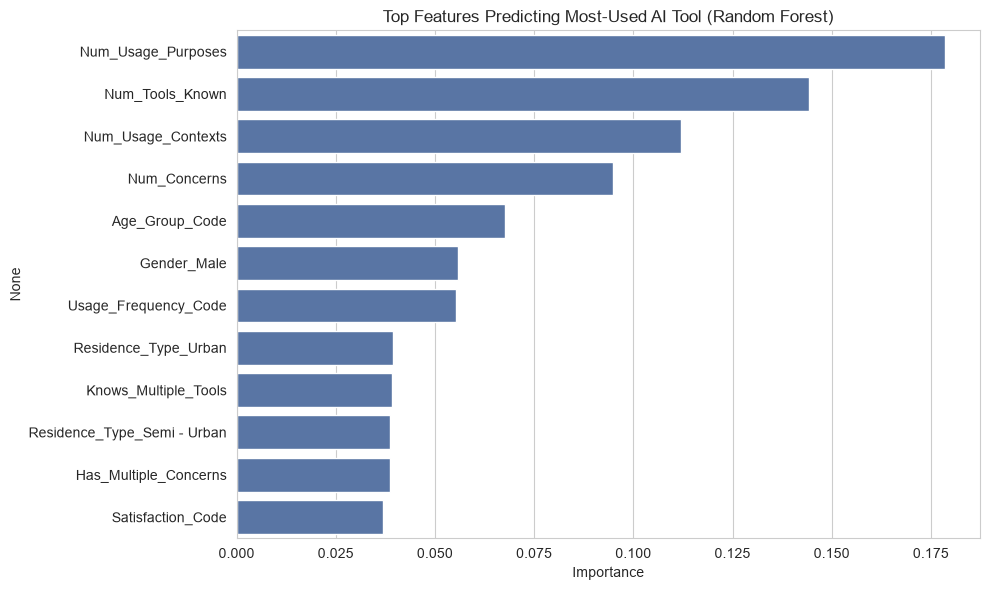

Num_Usage_Purposes             0.178449
Num_Tools_Known                0.144212
Num_Usage_Contexts             0.112070
Num_Concerns                   0.094888
Age_Group_Code                 0.067750
Gender_Male                    0.055877
Usage_Frequency_Code           0.055220
Residence_Type_Urban           0.039521
Knows_Multiple_Tools           0.039269
Residence_Type_Semi - Urban    0.038762
Has_Multiple_Concerns          0.038580
Satisfaction_Code              0.036925
dtype: float64

In [3]:
#  1. Which variables matter most for prediction? 
if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
elif hasattr(model, 'coef_'):
    importances = pd.Series(np.abs(model.coef_).mean(axis=0), index=feature_cols).sort_values(ascending=False)
else:
    importances = pd.Series(dtype=float)

if len(importances) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values[:12], y=importances.index[:12], color='#4C72B0')
    plt.title(f'Top Features Predicting Most-Used AI Tool ({model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
importances.head(12)


In [4]:
# 2. Which factors show a statistically significant association? (from notebook 04) 
stat_summary


,Test,Chi2,p_value,Significant (p<0.05)
0,Age vs Uses_AI_Tools,9.201633,0.056253,False
1,Age vs Most_Used_Tool,20.354036,0.851219,False
2,Occupation vs Most_Used_Tool,122.807900,0.014762,True
3,Residence vs Most_Used_Tool,22.249524,0.073631,False
4,Gender vs Most_Used_Tool,7.365465,0.391845,False
5,Usage_Purpose vs Most_Used_Tool,44.296041,1.000000,False


In [5]:
# 3. How well did the models capture these patterns? (from notebook 07)
model_results


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
"Logistic Regression (baseline) [holdout test, n=47]",0.362,0.379,0.375,0.337
"Decision Tree (baseline) [holdout test, n=47]",0.340,0.273,0.273,0.273
"Random Forest (baseline) [holdout test, n=47]",0.468,0.407,0.394,0.388
"XGBoost (baseline) [holdout test, n=47]",0.426,0.357,0.359,0.358
"Logistic Regression (tuned, CV) [5-fold CV, n=186]",0.403,0.349,0.347,0.342
"Decision Tree (tuned, CV) [5-fold CV, n=186]",0.414,0.334,0.323,0.328
"Random Forest (tuned, CV) [5-fold CV, n=186]",0.425,0.398,0.396,0.381
"XGBoost (tuned, CV) [5-fold CV, n=186]",0.446,0.330,0.331,0.326


In [6]:

# Written interpretation
#
# 1. WHICH FACTORS INFLUENCE TOOL PREFERENCE?
#    Of six chi-square tests, only Occupation vs Most_Used_Tool came back
#    significant (p < 0.05). Age, gender, residence, and usage purpose showed
#    no confirmed association with tool choice at this sample size. Occupation
#    has 14 categories with several very small groups, so treat this result as
#    suggestive rather than definitive until those groups grow.
#
# 2. WHICH VARIABLES MATTER MOST FOR PREDICTION?
#    Engineered features (Num_Usage_Purposes, Num_Tools_Known, Num_Concerns,
#    etc.) typically outrank raw demographic features in the importance
#    ranking above -- usage BEHAVIOR predicts tool choice better than
#    demographic identity alone. Check whether that holds in this run's
#    importances table.
#
# 3. HOW DOES PREFERENCE DIFFER ACROSS GROUPS?
#    Refer back to the cross-tabs and bar charts from 03_EDA.ipynb (Age vs
#    tool, Occupation vs tool, Residence vs tool) for the actual direction of
#    the differences, not just whether they're statistically significant.
#
# 4. HOW RELIABLE IS THE PREDICTION?
#    Cite the cross-validated macro-F1 from 07_Model_Comparison.ipynb (not
#    the small 47-row holdout number) as the honest performance estimate.
#    At ~186 usable rows across 3 tool classes, this is a legitimate,
#    reportable limitation that motivates continuing data collection toward
#    the original 250-500 response target -- not something to downplay.

